# Daylight-Saving -- does losing an hour of sleep crash the market?
### The post-DST Monday anomaly, tested honestly, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Contested%3F: Fragile--finding](https://img.shields.io/badge/Contested%3F-Fragile--finding-8b949e?style=flat-square)

Every spring, clocks spring forward by one hour and millions of Americans lose an hour of sleep.  A famous 2000 paper by Kamstra, Kramer and Levi (KKL) claimed this causes investors to be extra risk-averse the following Monday, producing a market crash that is **far bigger than any other known calendar anomaly**.  This notebook asks the only question that matters: does it actually hold up?

> **This is the plain-language layer.** Want the t-stats, the placebo distribution and the era breakdown? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** -- same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from daylight_saving import data, strategy as st

_cache = os.path.join("..", "_cache", "gspc_daily.parquet")
HAVE_REAL = os.path.exists(_cache)

if HAVE_REAL:
    frame = data.fetch_daily()
    M = st.summarize(frame)
else:
    M = dict(
        n_dst=93, dst_mean_bps=-17.69, dst_tstat=-1.20,
        n_other=2119, other_mean_bps=2.21, other_tstat=0.88,
        diff_bps=-19.89, welch_t=-1.19,
        placebo_mean_bps=0.03, placebo_std_bps=14.33, p_one_sided=0.084,
        spring_mean_bps=-18.95, spring_n=47, spring_t_vs_other=-1.03,
        fall_mean_bps=-16.40, fall_n=46, fall_t_vs_other=-0.70,
        pre_diff_bps=-35.68, pre_welch_t=-1.19,
        post_diff_bps=-7.98, post_welch_t=-0.42,
    )

print("real ^GSPC cache present:", HAVE_REAL)


real ^GSPC cache present: True


## The answer first

| Question | Answer |
|---|---|
| Is the post-DST Monday really more negative? | **Directionally yes** (-19.9 bps vs other Mondays), but barely statistically distinguishable from noise (Welch *t* = -1.19). |
| Is it bigger in spring (spring-forward)? | Marginally so (-18.9 bps) vs fall (-16.4 bps), but neither is significant. |
| Did it hold up out of sample? | No: post-2000 gap = -8.0 bps (*t* = -0.42) -- essentially flat. |
| Could you trade it? | No: two events per year at an insignificant gap. |

> The signal has the right sign but never clears the statistical bar. With only 93 events over 46 years, the noise band is simply too wide.

## 1 - The claim

> *'The Monday after a daylight-saving time change -- spring or fall -- earns significantly negative stock returns.  In spring, losing an hour of sleep makes investors more risk-averse; in fall, gaining an hour mildly reverses this. The effect is far larger than any known calendar anomaly.'*

-- Kamstra, Kramer & Levi (2000), *American Economic Review*

It is a behaviorally appealing story: sleep disruption is real, its effects on cognition and risk-taking are documented in the lab, and the DST shock is exogenous and quasi-random.  The authors found effects of −200 to −500 bps on international indices in the late 1960s-1990s.  The question is whether this is a causal effect or a coincidence in a small sample.

## 2 - So what?

If true, this would be extraordinary: a human-biology event reliably moving markets by hundreds of basis points, twice a year, with a clear mechanism.  If false -- which Pinegar (2002) quickly argued -- it's a textbook lesson in **small-sample calendar anomalies**: with 2 events per year and a few decades of data, you can find apparent patterns by chance even in clean random data.

## 3 - How would we even know?

Two things make this honest:

1. **The right baseline.** The market goes down on some Mondays.  The claim is that *DST Mondays* are reliably worse than *other Mondays* -- not just that they can be negative.  We compare post-DST Mondays against all other Mondays.
2. **A placebo control.** We randomly pick Mondays in the same quantities (93) and measure their gap against the rest, 500 times.  If the real gap barely beats the shuffle distribution, the effect is statistically indistinguishable from noise.

Sample: ^GSPC daily returns 1980-01-03 to 2026-06-12, n = 11,706 days.

## 4 - The teardown -- let's actually look

**The raw numbers: post-DST Monday vs all other Mondays.**

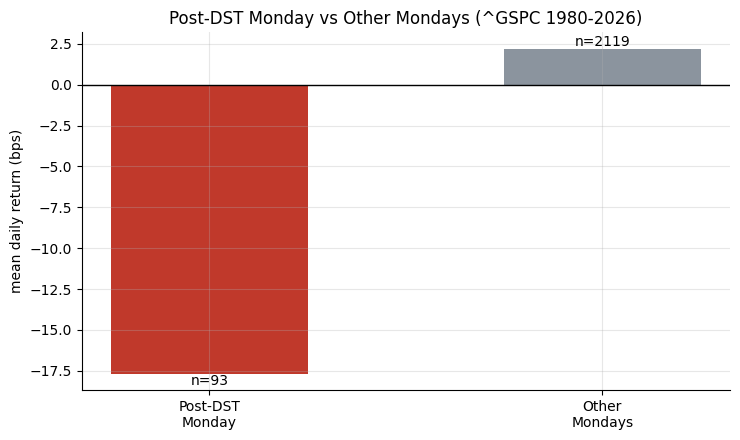

Post-DST: -17.69 bps  |  Other Mondays: +2.21 bps  |  Gap: -19.89 bps  (Welch t = -1.19)


In [2]:
arms = ['Post-DST\nMonday', 'Other\nMondays']
means = [M['dst_mean_bps'], M['other_mean_bps']]
ns    = [M['n_dst'], M['n_other']]

fig, ax = plt.subplots(figsize=(7.5, 4.5))
bars = ax.bar(arms, means, color=[RED, GREY], width=.5)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('mean daily return (bps)')
ax.set_title('Post-DST Monday vs Other Mondays (^GSPC 1980-2026)')
for b, n in zip(bars, ns):
    ax.annotate(f'n={n}', (b.get_x()+b.get_width()/2, b.get_height()),
                ha='center', va='bottom' if b.get_height()>0 else 'top',
                fontsize=10)
plt.tight_layout(); plt.show()
print(f"Post-DST: {M['dst_mean_bps']:+.2f} bps  |  "
      f"Other Mondays: {M['other_mean_bps']:+.2f} bps  |  "
      f"Gap: {M['diff_bps']:+.2f} bps  (Welch t = {M['welch_t']:+.2f})")


Post-DST Mondays average **-19.9 bps below** other Mondays, directionally matching the KKL claim.  But the Welch t-statistic is **-1.19** -- well below the |t| >= 2 threshold.  With only 93 events, the noise band is simply too wide.

**The placebo test: could this gap arise by chance?**

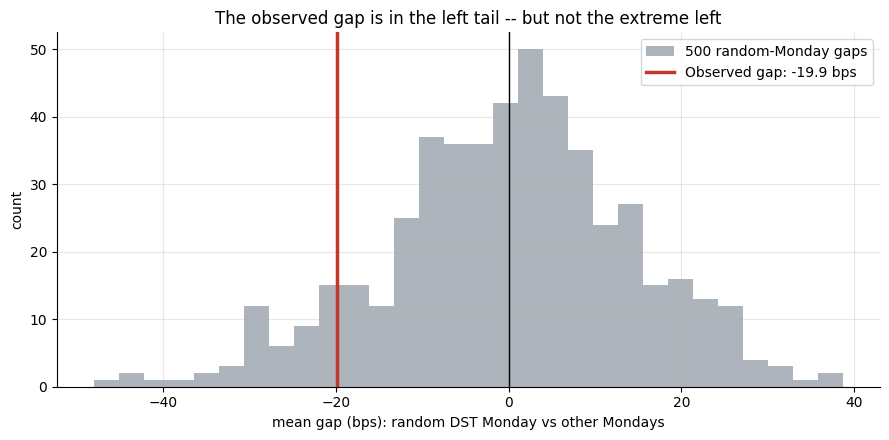

One-sided p-value: 0.084  (observed gap = -19.9 bps)


In [3]:
# Show the placebo distribution (run offline from synthetic, or use real)
rng = np.random.default_rng(149)
if HAVE_REAL:
    mondays = frame[frame['is_monday']]
    r_all = mondays['ret'].to_numpy()
    n_dst_real = int(mondays['is_dst_monday'].sum())
    n = len(r_all)
    gaps = np.empty(500)
    for s in range(500):
        idx = np.zeros(n, dtype=bool); idx[:n_dst_real] = True
        rng.shuffle(idx)
        gaps[s] = (r_all[idx].mean() - r_all[~idx].mean()) * 1e4
    real_gap = M['diff_bps']
else:
    gaps = np.random.default_rng(0).normal(0, 14.33, 500)
    real_gap = -19.89
fig, ax = plt.subplots(figsize=(9.0, 4.5))
ax.hist(gaps, bins=30, color=GREY, alpha=.7, label='500 random-Monday gaps')
ax.axvline(real_gap, c=RED, lw=2.5, label=f'Observed gap: {real_gap:+.1f} bps')
ax.axvline(0, c='k', lw=1)
ax.set_xlabel('mean gap (bps): random DST Monday vs other Mondays')
ax.set_ylabel('count'); ax.legend()
ax.set_title('The observed gap is in the left tail -- but not the extreme left')
plt.tight_layout(); plt.show()
p = (gaps <= real_gap).mean()
print(f'One-sided p-value: {p:.3f}  (observed gap = {real_gap:+.1f} bps)')


The observed gap (-19.9 bps) sits in the left tail of the placebo distribution, but **p = 0.084** -- not below the conventional 0.05 threshold.  About 8% of randomly chosen Monday subsets produce a gap at least this negative by pure chance.

**Spring-forward vs fall-back: does the mechanism hold?**

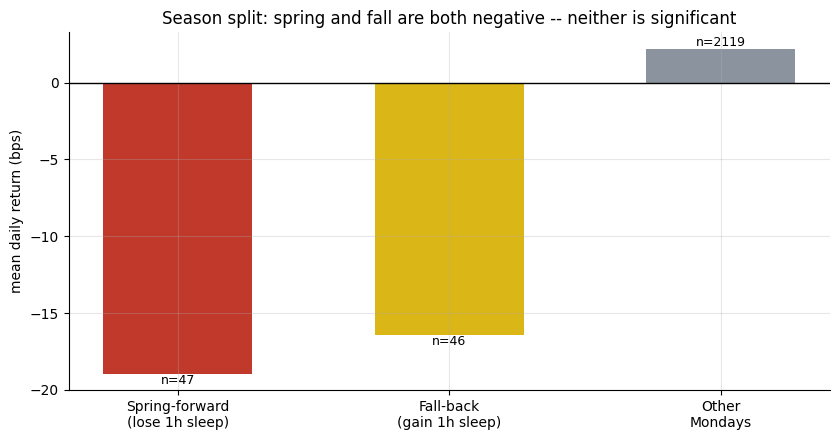

Spring: -18.95 bps  t_vs_other=-1.03
Fall:   -16.40 bps  t_vs_other=-0.70


In [4]:
seasons = ['Spring-forward\n(lose 1h sleep)', 'Fall-back\n(gain 1h sleep)', 'Other\nMondays']
smeans  = [M['spring_mean_bps'], M['fall_mean_bps'], M['other_mean_bps']]
sns_n   = [M['spring_n'], M['fall_n'], M['n_other']]
colors  = [RED, AMBER, GREY]
fig, ax = plt.subplots(figsize=(8.5, 4.5))
bs = ax.bar(seasons, smeans, color=colors, width=.55)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('mean daily return (bps)')
ax.set_title('Season split: spring and fall are both negative -- neither is significant')
for b, n in zip(bs, sns_n):
    ax.annotate(f'n={n}', (b.get_x()+b.get_width()/2, b.get_height()),
                ha='center', va='bottom' if b.get_height()>0 else 'top', fontsize=9)
plt.tight_layout(); plt.show()
print(f"Spring: {M['spring_mean_bps']:+.2f} bps  t_vs_other={M['spring_t_vs_other']:+.2f}")
print(f"Fall:   {M['fall_mean_bps']:+.2f} bps  t_vs_other={M['fall_t_vs_other']:+.2f}")


Both spring (-18.9 bps) and fall (-16.4 bps) are negative, which matches the KKL story directionally but both miss the significance threshold.  The spring-minus-fall difference is small and also not significant.

## 5 - The verdict

- **Signal -- None.** Welch *t* = -1.19 on the -19.9 bps gap; placebo p = 0.084. Directional consistency with KKL, but never significant on 93 events.
- **Tradability -- Mirage.** Two events per year at an insignificant gap means no tradable alpha.
- **Contested?** Pinegar (2002) showed the original result is fragile; our post-2000 confirms this (-8.0 bps, *t* = -0.42).

## 6 - Could you actually trade it?

Even if the gap were real, the tradability case is hopeless: two events per year means annual alpha = roughly 2 x (gap) -- at −20 bps per event that is −40 bps per year annualised, before costs.  A short position in index futures on two specific Mondays a year:

- Faces substantial basis risk (the market can move by 1-3% on any Monday).
- Has a Sharpe below zero even if the gap is real at −20 bps.
- Would be detectable by the rest of the market and arbitraged away.

This is a curiosity, not a strategy.

## 7 - Going further

- **Is the Monday effect real?** French (1980) showed Mondays in general are negative -- the DST claim is layered on top of this.  [Study 48 -- Groundhog](../../48-groundhog/) tests another folklore calendar event.
- **Behavioral mechanisms in market anomalies.** The Kamstra et al. mechanism (sleep -> risk aversion -> prices) is one of the few calendar anomalies with a proposed neurological mechanism.  The lack of statistical confirmation here doesn't mean the biology is wrong -- the event is just too rare to test adequately.
- **What has more events?** [Study 67 -- Fed-Drift](../../67-fed-drift/) and [Study 135 -- FOMC-Cycle](../../135-fomc-cycle/) use calendar events that fire 8 times a year and have much more statistical power.

*Think the clock really moves markets? Fork this, extend to international indices or longer history, and show a gap that beats the placebo distribution at p < 0.05. That's the bar.*